In [105]:
import numpy as np  # for fast array and mathematical operations
import pandas as pd # pandas to handle tabular data (Dataframes)
import matplotlib.pyplot as plt # generating plots n charts 


In [106]:
# # Visualize the sigmoid and how thresholds map probabilities -> classes
# z=np.linspace(-8,8,400)  # linspace - creates linear spaces- a sequence of number with equal spacing between them
# sigmoid = 1 / (1 + np.exp(-z))
# plt.figure(figsize=(8, 4))
# plt.plot(z, sigmoid, label="sigmoid(z) = 1 / (1 + exp(-z))")


In [107]:
# Import display function to format outputs beautifully in Jupyter
from IPython.display import display
# Import scikit-learn components
# 1.Dataset generation
from sklearn.datasets import load_breast_cancer,fetch_california_housing,make_classification

# 2.Components to split data into train test 
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    )
# 3.Building Machine Learning pipelines
from sklearn.pipeline import Pipeline
# 4. Feature scaling standardizer
from sklearn.preprocessing import StandardScaler
# 5. ML Model 
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
# 6.Evaluation metrics for classification performance 
from sklearn.metrics import (
    accuracy_score,               #overall correctness
    precision_score,              #Quality of positive predictions
    recall_score,                 #Ability to find positive instances
    f1_score,                     # Harmonic mean of precision and recall
    roc_auc_score,                #Area under roc curve
    RocCurveDisplay,
    confusion_matrix,             # matix of true and false predictions
    ConfusionMatrixDisplay  ,      # visual representation of confusion matrix
    classification_report,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

1. Problem and the Dataset (Classification) :

We will Convert the dataset into a dataframe and do some EDA to check for missing values , we check the target column values for class balance analysis ,as there are no missing values and the data is clean , we move forward with EDA and visualize our dataset using seaborn to get better insight into our data. 



In [108]:
# 1. Load Breast cancer Dataset as a dataframe 
breast_can_= load_breast_cancer(as_frame=True)
 
# 2. Separate feature(X) n Target (Y)
X_df=breast_can_.data.copy()
y=breast_can_.target.copy()
X_df

# 3. Combine for better EDA
df_bc=X_df.copy()
df_bc["target"]=y
df_bc
print(f'The dataset has {df_bc.shape[0]} rows and {df_bc.shape[1]} columns')

The dataset has 569 rows and 31 columns


In [109]:
print(f'Class Balance:')
print(f'{y.value_counts()}')
## Check for Nulls
df_bc.info()



Class Balance:
target
1    357
0    212
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               

In [110]:
df_bc.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [111]:
df_bc

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


Let's Visualize Our Dataset :
- Finding corelations between features 
-

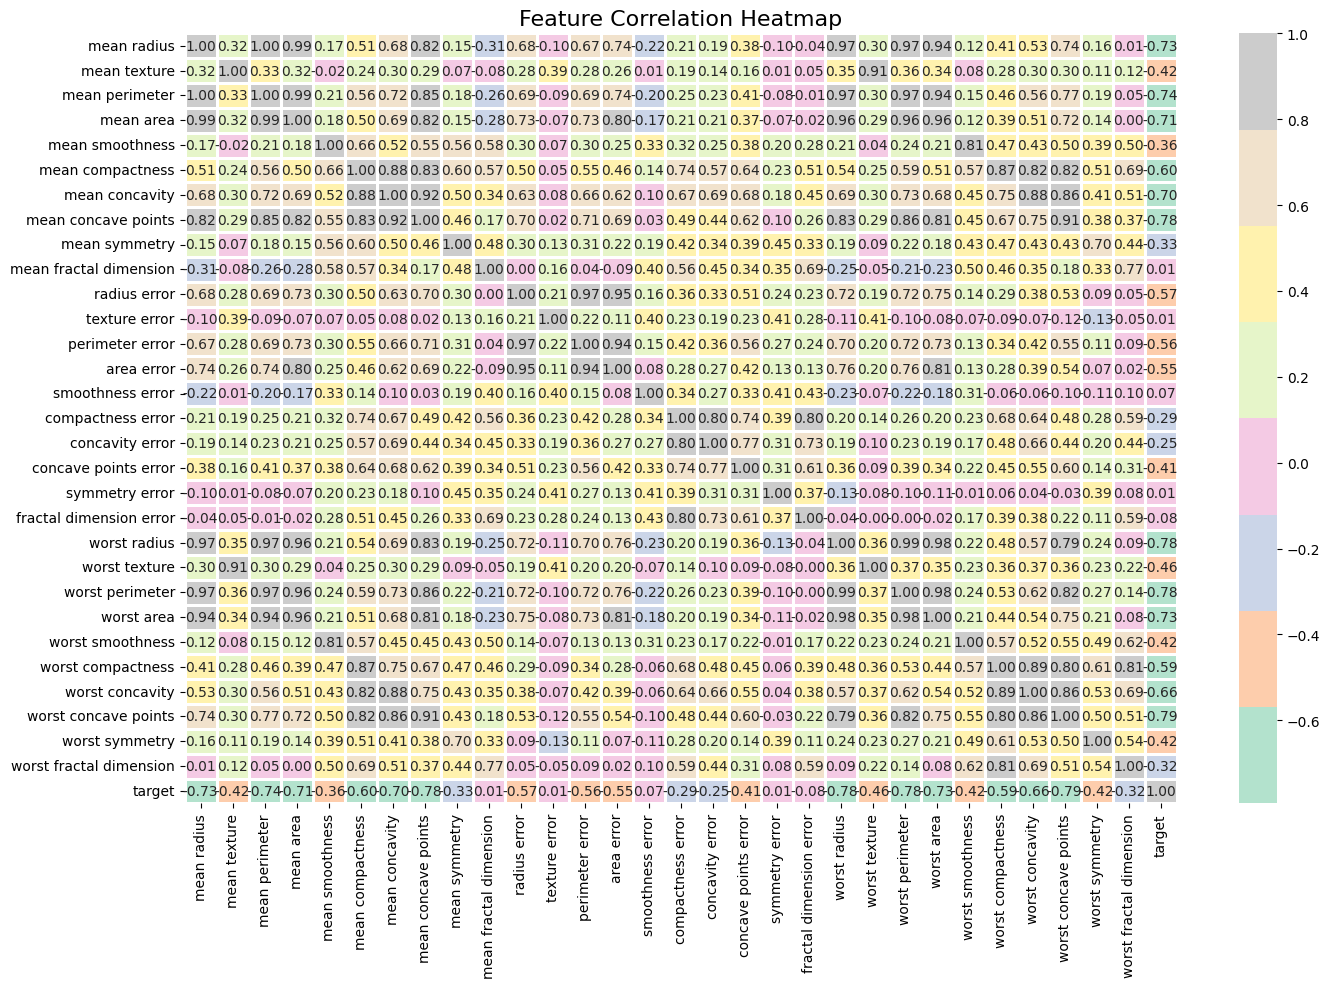

In [112]:
import seaborn as sns
plt.figure(figsize=(16, 10))
sns.heatmap(df_bc.corr(),annot=True,fmt='.2f',cmap='Pastel2',linewidths=2)
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.show()

1.Value Close to +1 shows strong positive correlation,whereas values closer to -1 shows strong negative correlation and values close to 0 has no linear correlation.

Train/Test Split & Baseline (The "Dumb" Model)

In [113]:
# Spliting the dataset into train test split , we train on 80% of data and test on 20 % of data 
# Stratify=y ensures that both training and testing datasets maitain the class balance.
X_train,X_test,y_train,y_test = train_test_split(X_df,y,train_size=0.8,random_state=42,stratify=y)
# Number of samples in Training and testing datasets
print(f'Training sample:{X_train.shape[0]},Test sample:{X_test.shape[0]}')
# Create a baseline prediction strategy that simply guesses the most frequent class in the training set
majority_class =(y_train.value_counts().idxmax())
# Generating an array matching test set filled with the majority class data
baseline_pred =np.full(shape=y_test.shape,fill_value=majority_class)
# Calculate evaluate metrics for our "dumb" baseline rule
baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)
# Display the baseline results
print(f"Majority class (from train): {majority_class}")
print(f"Baseline Accuracy: {baseline_acc:.3f}")
print(f"Baseline F1: {baseline_f1:.3f}")

Training sample:455,Test sample:114
Majority class (from train): 1
Baseline Accuracy: 0.632
Baseline F1: 0.774


Logistic Regression Model

In [114]:
# Define ML pipeline 
# Standardize the data followed by Logistic regression model creation
Log_reg_model =Pipeline([
#Step 1 Standardize features (mean =0,variance=1)
("scaler:",StandardScaler()),
#Step 2 Initialize ML Logistic regression model
(
    "logreg",LogisticRegression(max_iter=2000,random_state=42),),
])

In [115]:
# Train the dataset 
Log_reg_model.fit(X_train,y_train)
#y_proba = Log_reg_model.predict_proba(X_test)
y_proba = Log_reg_model.predict_proba(X_test)[:, 1]
chosen_threshold = 0.5
y_pred = (y_proba >= chosen_threshold).astype(int)
#y_pred=Log_reg_model.predict(X_train)
y_pred

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

Test-set metrics (threshold = 0.5)
Accuracy : 0.982
Precision: 0.986
Recall   : 0.986
F1-score : 0.986
ROC-AUC  : 0.995


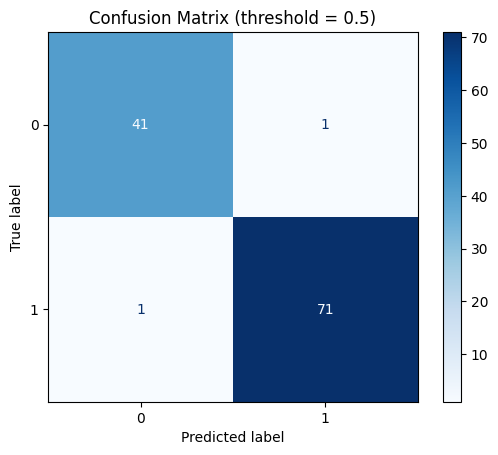

In [116]:
#  Calculate evaluation metrics based on predictions vs true labels
acc = accuracy_score(y_test, y_pred)       # Fraction of predictions that were completely correct
prec = precision_score(y_test, y_pred)     # Out of all predicted class 1s, what fraction were actually class 1
rec = recall_score(y_test, y_pred)         # Out of all actual class 1s, what fraction were correctly detected
f1 = f1_score(y_test, y_pred)              # Harmonic balance combining Precision and Recall
roc_auc = roc_auc_score(y_test, y_proba)   # Area under curve measuring class separability
# Print evaluated results
print("Test-set metrics (threshold = 0.5)")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")
# Generate and visually plot a Confusion Matrix to break down correct predictions and mistakes
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix (threshold = 0.5)")
plt.show()

Decision Threshold 

In [117]:
# Define a list of test boundary rules (Decision Thresholds) to experiment with
thresholds = [0.3, 0.5, 0.7]
# Create an empty list to capture metric results over different iterations
rows = []
# Loop through each configured threshold boundary
for t in thresholds:
     # Step 1: Force prediction to 1 if confidence score >= current threshold, else 0
     pred_t=(y_proba>=t).astype(int)
     # step 2 : Add Calculated metrics into a dictionary 
     rows.append(
          {
               "threshold":t,
               "accuracy":accuracy_score(y_test,pred_t),
               "precision":precision_score(y_test,pred_t,zero_division=0),
               "F1 Score":f1_score(y_test,pred_t),
               "Recall":recall_score(y_test,pred_t,zero_division=0)
          }
     )
# Convert Dictionary into dataframe     
thresholds_df=pd.DataFrame(rows)
display(thresholds_df)

,threshold,accuracy,precision,F1 Score,Recall
0,0.3,0.982456,0.972973,0.986301,1.000000
1,0.5,0.982456,0.986111,0.986111,0.986111
2,0.7,0.947368,0.985294,0.957143,0.930556


 Regularization (L2 vs L1) with Cross‑Validation
In logistic regression, the main regularization knob is C:

Smaller C → stronger regularization (simpler model)
Larger C → weaker regularization (more flexible model)
We will use CV (Cross-Validation) to pick the best C on our training data.

In [118]:
# Define 30 potential "C" regularization strengths spanning logarithmically from 0.0001 (strong) to 10000 (weak)
# 
# Why logspace?
# - C controls regularization strength and usually matters across orders of magnitude.
# - We try values like 1e-4, 1e-3, ..., 1e4 instead of stepping linearly.
import numpy as np
Cs = np.logspace(-4, 4, 30)
# Common CV settings we will use for both L1 and L2
common_cv_kwargs = dict(
    Cs=Cs,
    cv=5, # 5 data chunks
    max_iter=5000,
    scoring="roc_auc",
    random_state=42,
)

L2 Regularization

In [119]:
lr_l2 = LogisticRegressionCV(solver="lbfgs", l1_ratios=(0.0,), **common_cv_kwargs)
logreg_l2_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg_cv", lr_l2),
])
logreg_l2_cv.fit(X_train, y_train)
chosen_c_l2 = float(logreg_l2_cv.named_steps["logreg_cv"].C_[0])
print(f"Chosen C for L2: {chosen_c_l2:.6g}")

c:\Users\ali59\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Chosen C for L2: 0.0573615


L1 Regularization

In [120]:
lr_l1 = LogisticRegressionCV(solver="saga", l1_ratios=(1.0,), **common_cv_kwargs)
logreg_l1_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg_cv", lr_l1),
])
logreg_l1_cv.fit(X_train, y_train)
chosen_c_l1 = float(logreg_l1_cv.named_steps["logreg_cv"].C_[0])
print(f"Chosen C for L1: {chosen_c_l1:.6g}")
# Analyze feature relevance determined by L1 logic: count coefficients very close to 0
coef_l1 = logreg_l1_cv.named_steps["logreg_cv"].coef_.ravel()
near_zero = int(np.sum(np.abs(coef_l1) < 1e-8))
print(f"L1 near-zero coefficients: {near_zero} out of {coef_l1.size}")

c:\Users\ali59\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
  warnings.warn(


Chosen C for L1: 0.204336
L1 near-zero coefficients: 21 out of 30


Model Comparison : Logistic Regression (default) Vs Logistic Regression L2 CV Vs Logistic Regression L1 CV

In [121]:
models = {
    "LogReg (default)": Log_reg_model,
    "LogRegCV (L2)": logreg_l2_cv,
    "LogRegCV (L1)": logreg_l1_cv,
}
rows = []
for name, model in models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append(
        {
            "model": name,
            "accuracy": accuracy_score(y_test, pred),
            "precision": precision_score(y_test, pred),
            "recall": recall_score(y_test, pred),
            "f1": f1_score(y_test, pred),
            "roc_auc": roc_auc_score(y_test, proba),
        }
    )
results = pd.DataFrame(rows).set_index("model")
display(results)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogReg (default),0.982456,0.986111,0.986111,0.986111,0.995370
LogRegCV (L2),0.973684,0.972603,0.986111,0.979310,0.996032
LogRegCV (L1),0.964912,0.959459,0.986111,0.972603,0.996032


Decision Tree Model - Dataset: Breast Cancer (Binary classification) Goal: Predict whether a tumor is malignant (1) or benign (0) from cell measurements.

Since the data has already been split and EDA has been performed for above logistic regression model we will proceed with building pipelines and building hyperparameter tunning. 


In [122]:
# import required libraries n tools 
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor,plot_tree


In [123]:
# Create a pipeline
# step 1 : Scaling , step 2: decision tree 
decision_tree_model=Pipeline([
   ( "scaler",StandardScaler()),
   ("model",DecisionTreeClassifier(
       max_depth=3,
       min_samples_leaf=5,
       random_state=42
   ))
])
#step 3: train the model 
decision_tree_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [124]:
# step 4: Predict 
y_pred_train=decision_tree_model.predict(X_train)
y_pred_test=decision_tree_model.predict(X_test)

# Evaluate
# Evaluate
print("Train Accuracy:", round(accuracy_score(y_train, y_pred_train), 3))
print("Test Accuracy: ", round(accuracy_score(y_test, y_pred_test), 3))

Train Accuracy: 0.974
Test Accuracy:  0.939


How to visualize the tree?

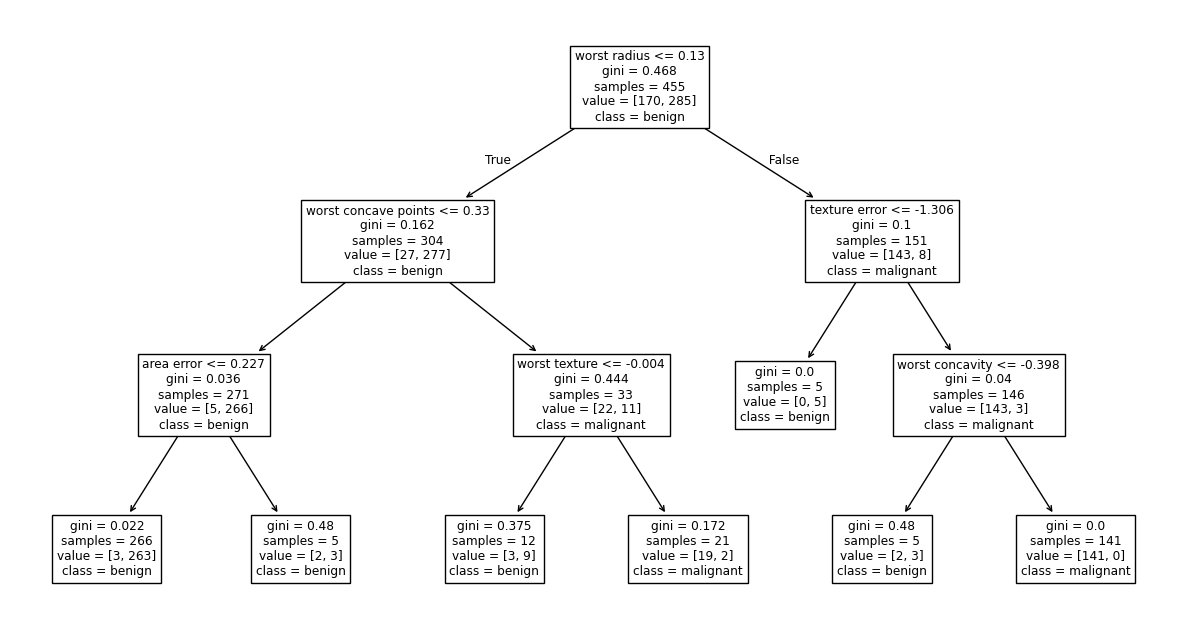

In [125]:
plt.figure(figsize=(15,8))
tree_model =decision_tree_model.named_steps["model"]  ## extract the model from the pipeline 
plot_tree(
    tree_model,
    class_names=["malignant","benign"],
    feature_names=X_df.columns
)
plt.show()

Decision Tree Regressor Model 

Root Mean Squared Error: 0.24 (Average prediction error magnitude)


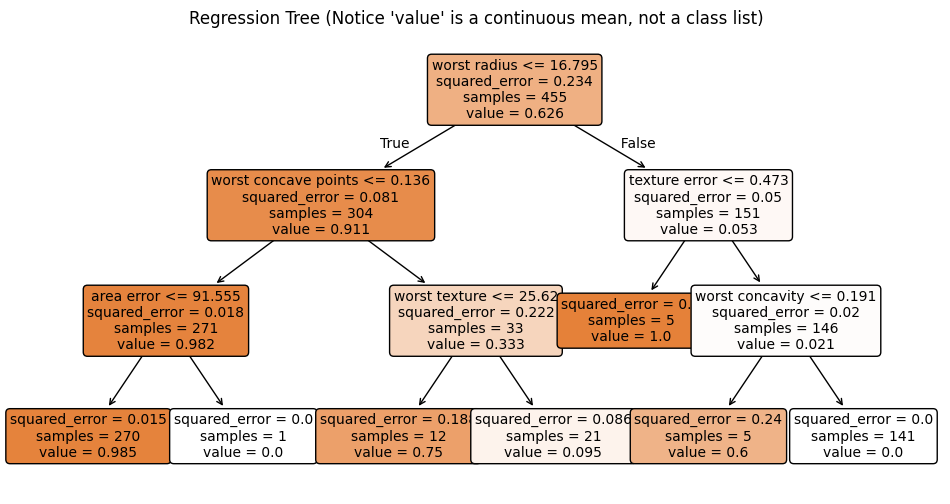

In [126]:
# 1. Model: Notice we use DecisionTreeRegressor!
reg_tree = DecisionTreeRegressor(max_depth=3, random_state=42)

# 2. Train
reg_tree.fit(X_train, y_train)

# 3. Predict
y_pred_reg = reg_tree.predict(X_test)


# 4. Evaluate using RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_pred_reg, y_test))
print(f"Root Mean Squared Error: {rmse:.2f} (Average prediction error magnitude)")

# Show tree outputting continuous Values
plt.figure(figsize=(12, 6))
plot_tree(reg_tree, feature_names=X_train.columns, filled=True, rounded=True, fontsize=10)
plt.title("Regression Tree (Notice 'value' is a continuous mean, not a class list)")
plt.show()


Random Forest for Classification

In [129]:
# Initialize the Random Forest Classifier
rf_clf = RandomForestClassifier(
    n_estimators=400,          # 1. How many trees in our "Board of Directors"?
    max_features="sqrt",       # 2. Force diversity: each tree only sees a random subset of features per split
    oob_score=True,            # 3. Built-in validation: evaluate trees on the 1/3 of data they didn't train on
    random_state=42,        # 4. Consistency for reproducibility
    n_jobs=-1                  # 5. Use all CPU cores to train the 400 trees in parallel at lightning speed!
)
# Train the model 
rf_clf.fit(X_train,y_train)
#Predictions & probability 
y_pred=rf_clf.predict(X_test)
y_prob_rf=rf_clf.predict_proba(X_test)[:,1] # Probability of being class "1" (Benign)

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Test F1:", round(f1_score(y_test, y_pred), 4))
print("Test ROC AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("\nOOB Score:", round(rf_clf.oob_score_, 4))


Test accuracy: 0.9561
Test F1: 0.9655
Test ROC AUC: 0.9954

OOB Score: 0.9604
